In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg
from scipy.linalg import toeplitz, cholesky
from gaussian_crossings import simulate_gaussian_process_fft, simulate_gaussian_process_cholesky

In [3]:
def r(t, tau, sigma):
    return sigma ** 2 * np.exp(- (t/ tau) ** 2)

# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
dt = 0.01   # Time discretization step
tau = 1.0   # Correlation decay parameter
sigma = 0.5 # Standard deviation (amplitude) of the process

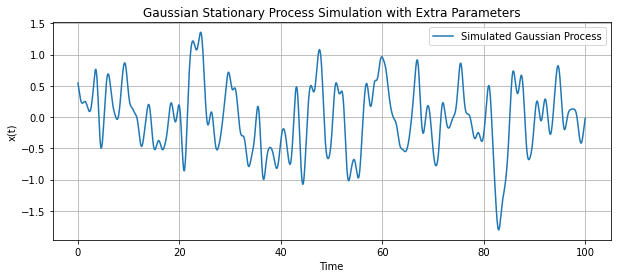

In [4]:
n = int(round(T / dt))
t = np.linspace(0, T, n)
N = 2 * n - 2
r_vals = np.array([r(i * dt, tau=tau, sigma=sigma) for i in range(n)])
c = np.concatenate((r_vals, np.flip(r_vals)[1:-1]))
lam = scipy.fft.fft(c)
Z = np.random.randn(N) + 1j * np.random.randn(N)
Y = np.sqrt(lam / N) * Z
V = scipy.fft.fft(Y)
# V1 = scipy.fft.ifft(np.conjugate(Y)) * N

X = np.real(V[:n])

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, X, label='Simulated Gaussian Process')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Gaussian Stationary Process Simulation with Extra Parameters')
plt.legend()
plt.grid(True)
plt.show()

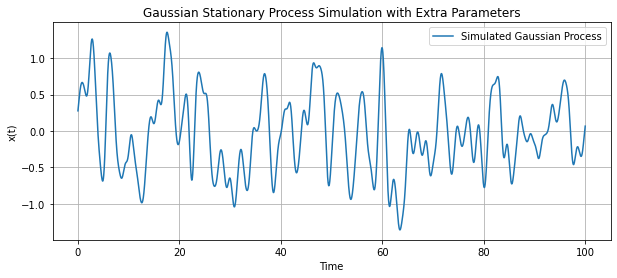

In [5]:
t, x = simulate_gaussian_process_cholesky(r, T, dt, tau=tau, sigma=sigma)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='Simulated Gaussian Process')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Gaussian Stationary Process Simulation with Extra Parameters')
plt.legend()
plt.grid(True)
plt.show()

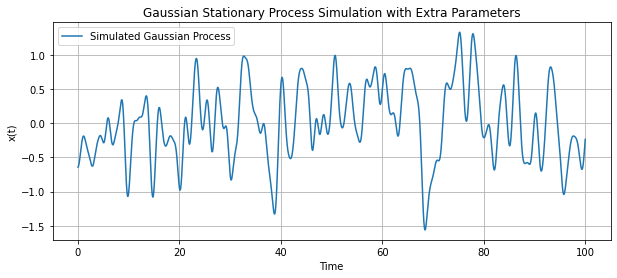

In [6]:
t, x = simulate_gaussian_process_fft(r, T, dt, tau=tau, sigma=sigma)

# Plot the result.
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='Simulated Gaussian Process')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Gaussian Stationary Process Simulation with Extra Parameters')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# using code from miranda's lecture notes
N = int(round(T / dt))
t = np.linspace(0, T, n)
N = 2 * n - 2


/Users/shivang/anaconda3/envs/conda-fr-whistler/lib/python3.11/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


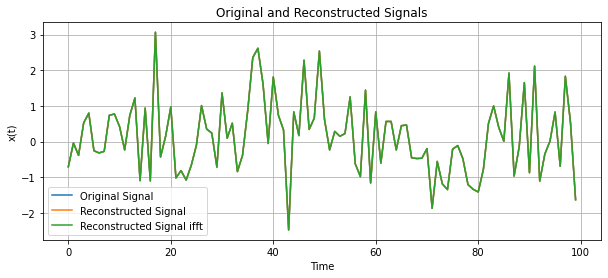

In [55]:
# here we test dft
n = 100
signal = np.random.randn(n)

# compute the DFT
F = scipy.fft.fft(signal)

# compute the inverse DFT
# signal_hat = scipy.fft.ifft(F)
signal_hat = scipy.fft.fft(np.conjugate(F)) / n

signal_ifft = scipy.fft.ifft(F)

# plot the original signal and the reconstructed signal
plt.figure(figsize=(10, 4))
plt.plot(signal, label='Original Signal')
plt.plot(signal_hat, label='Reconstructed Signal')
plt.plot(signal_ifft, label='Reconstructed Signal ifft')
plt.xlabel('Time')
plt.ylabel('x(t)')
plt.title('Original and Reconstructed Signals')
plt.legend()
plt.grid(True)
plt.show()
